# Lecture 1 (Extended Materials), Notebook 02: Random Search and Successive Halving from Scratch

**Course:** CEMRACS 2026 Summer School — Modeling and AI for Environmental Transition · Lecture 1 (July 14, 2026, CIRM, Marseille)  
**Script reference:** §4.3 (random search), §4.5 (Hyperband and successive halving), §4.7 (implementing the search in practice)  
**Notebook role:** core  
**Author:** Simon Scheidegger (HEC Lausanne · Grantham Research Institute, LSE)  

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


Accompanies **Session 2 — Neural Architecture Search** (slides: `02_01_neural_architecture_search.pdf`).

We implement the two key automated-search algorithms from §4 of the lecture
script directly, without relying on a hyperparameter-tuning library. The search
space and target task are the same as in the slides (Genz Gaussian on
$[0,1]^2$, search over depth/width/activation/learning rate), which lets you
read off the algorithm logic with no extra abstraction.

> **Production tooling.** Real projects rarely hand-roll the search loop.
> Established libraries wrap (and parallelize) the same algorithms: KerasTuner,
> Optuna, Ray Tune, Hyperopt, Ax/BoTorch, NNI, AutoKeras. We mention them here
> for completeness; the algorithms below are what they all implement
> underneath.

This is the **second of two hands-on NAS examples** for Session 2:

| Notebook | Method | Testbed |
|:--|:--|:--|
| `02_NAS_Random_Search_10D.ipynb` | Random Search, no external library | 10-D analytical regression |
| `03_NAS_RandomSearch_Hyperband.ipynb` *(this notebook)* | Random Search + Successive Halving, from scratch | Genz Gaussian on $[0,1]^2$ |

---

**Goals**

1. Understand why architecture choice matters for function approximation.
2. Implement Random Search as a transparent Python loop.
3. Implement Successive Halving (the building block of Hyperband) as a
   transparent Python loop.
4. Compare both against a fixed baseline on the Genz Gaussian test function.

**Outline**

| Section | Topic |
|:--------|:------|
| 1 | Setup and data generation |
| 2 | Baseline: fixed architecture |
| 3 | Search space and trial helper |
| 4 | Random Search from scratch |
| 5 | Successive Halving from scratch |
| 6 | Comparison and best-model surface |
| 7 | Discussion |

In [1]:
# ----------------------------------------------------------------
# Imports and plot style
# ----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import time
import os
import pickle
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Consistent plot style (project convention: font.size = 13)
rcParams.update({
    "figure.dpi":       120,
    "font.size":        13,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "legend.fontsize":  10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "font.family":      "serif",
    "mathtext.fontset":  "cm",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
})

# Colour palette
C_RANDOM  = "#e76f51"   # orange-red, Random Search
C_SHA     = "#2a9d8f"   # teal,       Successive Halving
C_BASE    = "#6c757d"   # grey,       fixed baseline
C_TRUE    = "#457b9d"   # steel blue, ground truth

# Reproducibility (SEED comes from the run-mode-switch cell at the top).
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Cache location for trial records (re-runs short-circuit if present)
CACHE_DIR  = Path("nas_results")
CACHE_DIR.mkdir(exist_ok=True)
CACHE_PATH = CACHE_DIR / "search_records.pkl"

print(f"TensorFlow version: {tf.__version__}")
print(f"Cache file       : {CACHE_PATH}")


2026-04-26 11:55:12.723348: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777197312.740151  411434 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777197312.745101  411434 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-26 11:55:12.770138: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
Cache file       : nas_results/search_records.pkl


---
## 1. The NAS Problem

**Neural Architecture Search (NAS)** aims to find the best network
architecture for a given task *automatically*.

The **search space** includes:
- Number of hidden layers
- Number of units per layer
- Activation function
- Learning rate

We use the **Genz Gaussian** function on $[0,1]^2$ as our test case:
$$f(\mathbf{x}) = \exp\!\left(-\sum_{i=1}^d c_i^2 (x_i - w_i)^2\right)$$

In [2]:
# ----------------------------------------------------------------
# Define Genz Gaussian and generate data
# ----------------------------------------------------------------

def genz_gaussian(X, c, w):
    """f4: exp(-sum_i c_i^2 * (x_i - w_i)^2)"""
    return np.exp(-np.sum(c**2 * (X - w)**2, axis=1))

# Fixed parameters
d = 2
rng = np.random.RandomState(7)
c_param = rng.uniform(1.0, 3.0, size=d)
w_param = rng.uniform(0.2, 0.8, size=d)

# Training and test data
n_train = 1000
n_test = 2000

X_train = np.random.uniform(0, 1, size=(n_train, d)).astype(np.float32)
y_train = genz_gaussian(X_train, c_param, w_param).astype(np.float32)

X_test = np.random.uniform(0, 1, size=(n_test, d)).astype(np.float32)
y_test = genz_gaussian(X_test, c_param, w_param).astype(np.float32)

print(f"d = {d}, c = {c_param}, w = {w_param}")
print(f"Training: {n_train} points, Test: {n_test} points")
print(f"y_train range: [{y_train.min():.3f}, {y_train.max():.3f}]")

d = 2, c = [1.15261658 2.55983758], w = [0.46304554 0.63407911]
Training: 1000 points, Test: 2000 points
y_train range: [0.060, 1.000]


In [3]:
# ----------------------------------------------------------------
# Baseline: fixed 3 x 64 ReLU MLP, ~100 epochs
# ----------------------------------------------------------------

def build_fixed_model(n_layers=3, n_units=64, activation="relu", lr=1e-3):
    """Build a fixed-architecture MLP."""
    model = keras.Sequential()
    model.add(keras.Input(shape=(d,)))
    for _ in range(n_layers):
        model.add(layers.Dense(n_units, activation=activation))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="mse", metrics=["mae"])
    return model

t0 = time.time()
baseline_model = build_fixed_model()
baseline_history = baseline_model.fit(
    X_train, y_train, epochs=100, batch_size=64, verbose=0,
    validation_data=(X_test, y_test),
)
baseline_time = time.time() - t0

baseline_pred  = baseline_model.predict(X_test, verbose=0).flatten()
baseline_mae   = float(np.abs(baseline_pred - y_test).mean())
baseline_max   = float(np.abs(baseline_pred - y_test).max())
baseline_vloss = float(baseline_history.history["val_loss"][-1])

baseline_record = {
    "config":   {"layers": 3, "units": [64, 64, 64], "activation": "relu", "lr": 1e-3},
    "val_loss": baseline_vloss,
    "mae":      baseline_mae,
    "time":     baseline_time,
    "params":   int(baseline_model.count_params()),
}

print(f"Baseline (3x64 ReLU): MAE = {baseline_mae:.5f}, "
      f"max err = {baseline_max:.5f}, time = {baseline_time:.1f}s")
print(f"Baseline architecture: {baseline_record['params']} parameters")


2026-04-26 11:55:15.981039: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Baseline (3x64 ReLU): MAE = 0.00556, max err = 0.02280, time = 17.0s
Baseline architecture: 8577 parameters


---
## 3. Search space and `build_and_train` helper

Both Random Search and Successive Halving draw architectures from the same
search space:

| Hyperparameter | Range |
|:---|:---|
| `layers`       | $\{1, 2, 3, 4, 5\}$                          |
| `units` (per layer) | $\{32, 64, 96, \ldots, 256\}$           |
| `activation`   | $\{\mathrm{relu}, \mathrm{tanh}, \mathrm{swish}\}$ |
| `lr`           | log-uniform on $[10^{-4}, 10^{-2}]$           |

The trial helper `build_and_train(config, epochs)` builds the corresponding
`keras.Sequential` model and trains it for the requested number of epochs with
early stopping on validation loss. It returns the final validation loss and
wall-clock time. This is the only primitive the search algorithms below call.

In [4]:
# ----------------------------------------------------------------
# Search space and trial helper
# ----------------------------------------------------------------

LAYER_OPTIONS = [1, 2, 3, 4, 5]
UNIT_OPTIONS  = [32, 64, 96, 128, 160, 192, 224, 256]
ACT_OPTIONS   = ["relu", "tanh", "swish"]
LR_LOG_LO, LR_LOG_HI = -4.0, -2.0   # log10 bounds for learning rate


def sample_config(rng):
    """Draw one architecture uniformly from the search space."""
    n_layers = int(rng.choice(LAYER_OPTIONS))
    units    = [int(rng.choice(UNIT_OPTIONS)) for _ in range(n_layers)]
    act      = str(rng.choice(ACT_OPTIONS))
    lr       = float(10.0 ** rng.uniform(LR_LOG_LO, LR_LOG_HI))
    return {"layers": n_layers, "units": units, "activation": act, "lr": lr}


def build_model(config):
    """Build a Sequential MLP from a config dict."""
    model = keras.Sequential()
    model.add(keras.Input(shape=(d,)))
    for u in config["units"]:
        model.add(layers.Dense(u, activation=config["activation"]))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config["lr"]),
        loss="mse",
        metrics=["mae"],
    )
    return model


def build_and_train(config, epochs, X_tr, y_tr, X_val, y_val,
                    batch_size=64, patience=10, verbose=0):
    """Build, fit, and evaluate one trial. Returns a record dict.

    `model.fit` runs Keras' compiled training step (already JIT'd via
    `tf.function` internally), which keeps per-epoch overhead minimal.
    """
    model = build_model(config)
    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience,
        restore_best_weights=True, verbose=0,
    )
    t0 = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=verbose,
    )
    wall = time.time() - t0
    val_loss = float(min(history.history["val_loss"]))
    pred = model.predict(X_val, verbose=0).flatten()
    mae  = float(np.abs(pred - y_val).mean())
    return {
        "config":   config,
        "val_loss": val_loss,
        "mae":      mae,
        "time":     wall,
        "epochs":   len(history.history["val_loss"]),
        "params":   int(model.count_params()),
    }, model


# Quick smoke test
_demo_cfg = sample_config(np.random.default_rng(0))
print("Demo config :", _demo_cfg)


Demo config : {'layers': 5, 'units': [192, 160, 96, 96, 32], 'activation': 'relu', 'lr': 0.0042319495174775335}


In [5]:
# ----------------------------------------------------------------
# Cache: short-circuit on re-run if pickle is present
# ----------------------------------------------------------------
# We pickle a single dict
#     {"random": [...records...], "sha": [...records...], "baseline": {...}}
# to nas_results/search_records.pkl. The plotting cells below read that dict.
# Delete the file to force a fresh sweep.

cache = None
if CACHE_PATH.exists():
    with open(CACHE_PATH, "rb") as f:
        cache = pickle.load(f)
    print(f"Loaded cached records from {CACHE_PATH}")
    print(f"  random : {len(cache['random'])} trials")
    print(f"  sha    : {len(cache['sha'])} trials")
else:
    print(f"No cache at {CACHE_PATH}; the next two cells will run searches.")


No cache at nas_results/search_records.pkl; the next two cells will run searches.


---
## 4. Random Search from scratch

The loop is six lines of real logic. We sample $N=30$ architectures
independently from the search space, train each for a small fixed budget with
early stopping, and remember the best.

```text
for i = 1..N:
    cfg     <- sample_config()
    record  <- build_and_train(cfg, epochs=R)
    log(record)
return argmin val_loss over records
```

Random Search ignores the structure of the response surface, but it is
embarrassingly parallel and gives an honest baseline that more sophisticated
methods need to beat (Bergstra & Bengio, 2012).

In [6]:
# ----------------------------------------------------------------
# Random Search loop  (budget driven by RUN_MODE; teaching/production = 30 trials x ~50 epochs each)
# ----------------------------------------------------------------
if RUN_MODE == "smoke":
    N_RANDOM_TRIALS, RANDOM_EPOCHS = 8, 12
else:  # "teaching" / "production"
    N_RANDOM_TRIALS, RANDOM_EPOCHS = 30, 50

if cache is not None and "random" in cache:
    random_records = cache["random"]
    print(f"Random Search: using {len(random_records)} cached trials.")
else:
    rng_rs = np.random.default_rng(SEED)
    random_records = []
    t0_rs = time.time()
    for i in range(N_RANDOM_TRIALS):
        cfg = sample_config(rng_rs)
        rec, _ = build_and_train(
            cfg, epochs=RANDOM_EPOCHS,
            X_tr=X_train, y_tr=y_train,
            X_val=X_test, y_val=y_test,
        )
        random_records.append(rec)
        if (i + 1) % 5 == 0 or i == 0:
            best_so_far = min(r["val_loss"] for r in random_records)
            print(f"  trial {i+1:>2d}/{N_RANDOM_TRIALS}: "
                  f"val_loss={rec['val_loss']:.2e}  "
                  f"best={best_so_far:.2e}  "
                  f"({rec['epochs']} epochs, {rec['time']:.1f}s)")
    random_total_time = time.time() - t0_rs
    print(f"Random Search done in {random_total_time:.1f}s "
          f"({len(random_records)} trials)")

best_random = min(random_records, key=lambda r: r["val_loss"])
print(f"\nBest Random Search config : {best_random['config']}")
print(f"  val_loss = {best_random['val_loss']:.3e}, MAE = {best_random['mae']:.5f}")


  trial  1/30: val_loss=4.43e-02  best=4.43e-02  (14 epochs, 2.6s)


  trial  5/30: val_loss=2.68e-04  best=3.14e-06  (50 epochs, 7.4s)


  trial 10/30: val_loss=4.16e-04  best=3.14e-06  (50 epochs, 7.9s)


  trial 15/30: val_loss=6.08e-04  best=3.14e-06  (50 epochs, 8.1s)


  trial 20/30: val_loss=3.34e-03  best=3.14e-06  (34 epochs, 7.3s)


  trial 25/30: val_loss=2.80e-02  best=3.14e-06  (50 epochs, 6.0s)


  trial 30/30: val_loss=8.92e-06  best=2.38e-06  (50 epochs, 9.1s)
Random Search done in 222.0s (30 trials)

Best Random Search config : {'layers': 4, 'units': [192, 192, 128, 192], 'activation': 'relu', 'lr': 0.0010048229603696426}
  val_loss = 2.385e-06, MAE = 0.00120


---
## 5. Successive Halving from scratch

Successive Halving (SHA) is the inner loop of Hyperband (Li et al., 2018). The
idea: cheap configurations should be killed early, expensive ones promoted.

We use $n_0 = 27$ initial random configs and a halving rate $\eta = 3$, giving
three rounds and a 1-of-27 winner:

| Round | Configs alive | Epoch budget per config |
|:--|:--:|:--:|
| 0 | 27 | $r_0 = 8$  |
| 1 | 9  | $r_1 = 24$ |
| 2 | 3  | $r_2 = 72$ |
| 3 | 1  | (final winner) |

Each round, we train every surviving config for `r_k` epochs, sort by
validation loss, and keep the top $1/\eta$. The total epoch budget is roughly
matched to Random Search ($27 \cdot 8 + 9 \cdot 24 + 3 \cdot 72 \approx 648$
epoch-trials, vs $30 \cdot 50 = 1500$ for Random Search), but SHA spends most
of its compute on the promising tail.

In [7]:
# ----------------------------------------------------------------
# Successive Halving (SHA) loop
# ----------------------------------------------------------------
ETA = 3                # halving rate
if RUN_MODE == "smoke":
    N0_SHA, R0, N_ROUNDS = 9, 4, 2     # 9@4 -> 3@12 -> winner
else:  # "teaching" / "production"
    N0_SHA, R0, N_ROUNDS = 27, 8, 3    # 27@8 -> 9@24 -> 3@72 -> winner

if cache is not None and "sha" in cache:
    sha_records = cache["sha"]
    print(f"SHA: using {len(sha_records)} cached trials.")
else:
    rng_sha = np.random.default_rng(SEED + 1)
    # Round 0: sample n0 configs and train each for R0 epochs
    survivors = [sample_config(rng_sha) for _ in range(N0_SHA)]
    sha_records = []
    t0_sha = time.time()
    for k in range(N_ROUNDS):
        epochs_k = R0 * (ETA ** k)
        print(f"Round {k}: {len(survivors)} configs x {epochs_k} epochs")
        round_records = []
        for j, cfg in enumerate(survivors):
            rec, _ = build_and_train(
                cfg, epochs=epochs_k,
                X_tr=X_train, y_tr=y_train,
                X_val=X_test, y_val=y_test,
            )
            rec["round"] = k
            round_records.append(rec)
            sha_records.append(rec)
        # Promote top 1/eta
        round_records.sort(key=lambda r: r["val_loss"])
        n_keep = max(1, len(round_records) // ETA)
        survivors = [r["config"] for r in round_records[:n_keep]]
        print(f"  best this round : val_loss={round_records[0]['val_loss']:.2e}")
        print(f"  promoting top {n_keep} -> next round")
    sha_total_time = time.time() - t0_sha
    print(f"SHA done in {sha_total_time:.1f}s "
          f"(total trials evaluated: {len(sha_records)})")

best_sha = min(sha_records, key=lambda r: r["val_loss"])
print(f"\nBest SHA config : {best_sha['config']}")
print(f"  val_loss = {best_sha['val_loss']:.3e}, MAE = {best_sha['mae']:.5f}")


Round 0: 27 configs x 8 epochs


  best this round : val_loss=5.14e-04
  promoting top 9 -> next round
Round 1: 9 configs x 24 epochs


  best this round : val_loss=2.99e-06
  promoting top 3 -> next round
Round 2: 3 configs x 72 epochs


  best this round : val_loss=1.75e-06
  promoting top 1 -> next round
SHA done in 135.7s (total trials evaluated: 39)

Best SHA config : {'layers': 5, 'units': [256, 256, 224, 192, 128], 'activation': 'relu', 'lr': 0.0010026588780510212}
  val_loss = 1.753e-06, MAE = 0.00100


In [8]:
# ----------------------------------------------------------------
# Persist trial records so re-runs short-circuit
# ----------------------------------------------------------------
if cache is None:
    cache = {
        "random":   random_records,
        "sha":      sha_records,
        "baseline": baseline_record,
    }
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(cache, f)
    print(f"Wrote {CACHE_PATH} ({len(random_records)} RS + "
          f"{len(sha_records)} SHA records).")
else:
    print(f"Cache already on disk at {CACHE_PATH}; nothing to write.")


Wrote nas_results/search_records.pkl (30 RS + 39 SHA records).


---
## 6. Comparison and best-model surface

We plot the **best-so-far** validation loss against trial index for each
algorithm. The fixed baseline appears as a constant horizontal line. This is
the figure consumed by the slides as `nas_search_results.pdf`.

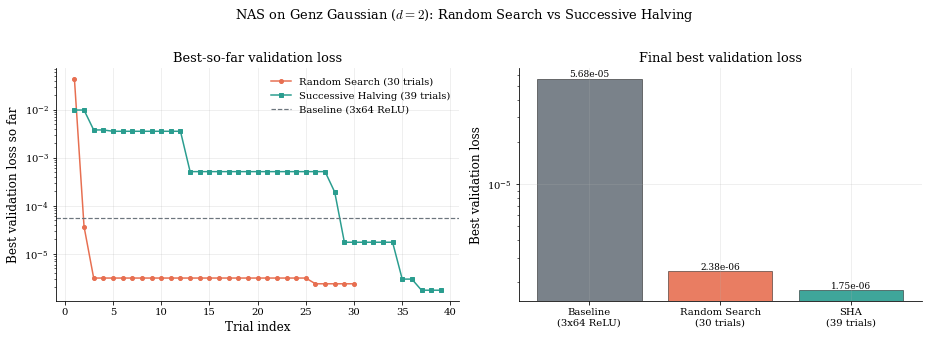


Method                   Best val_loss    Best MAE
--------------------------------------------------
Baseline (3x64 ReLU)         5.676e-05     0.00556
Random Search (30)           2.385e-06     0.00120
SHA (27/9/3/1)               1.753e-06     0.00100


In [9]:
# ----------------------------------------------------------------
# Figure 1: best-so-far comparison (saved as nas_search_results.{pdf,png})
# ----------------------------------------------------------------

def best_so_far(records):
    """Cumulative minimum of val_loss along the trial sequence."""
    out, m = [], np.inf
    for r in records:
        m = min(m, r["val_loss"])
        out.append(m)
    return np.asarray(out)

rs_curve  = best_so_far(random_records)
sha_curve = best_so_far(sha_records)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) Best-so-far validation loss vs trial index
ax = axes[0]
ax.plot(np.arange(1, len(rs_curve) + 1),  rs_curve,  marker="o", ms=4,
        color=C_RANDOM, label=f"Random Search ({len(rs_curve)} trials)")
ax.plot(np.arange(1, len(sha_curve) + 1), sha_curve, marker="s", ms=4,
        color=C_SHA,    label=f"Successive Halving ({len(sha_curve)} trials)")
ax.axhline(baseline_record["val_loss"], color=C_BASE, ls="--", lw=1.2,
           label=f"Baseline (3x64 ReLU)")
ax.set_yscale("log")
ax.set_xlabel("Trial index")
ax.set_ylabel("Best validation loss so far")
ax.set_title("Best-so-far validation loss")
ax.legend(loc="upper right", frameon=False)

# (b) Final best val_loss bar chart
ax = axes[1]
labels = ["Baseline\n(3x64 ReLU)",
          f"Random Search\n({len(random_records)} trials)",
          f"SHA\n({len(sha_records)} trials)"]
vals   = [baseline_record["val_loss"],
          float(rs_curve[-1]),
          float(sha_curve[-1])]
colors = [C_BASE, C_RANDOM, C_SHA]
bars = ax.bar(labels, vals, color=colors, alpha=0.9,
              edgecolor="black", linewidth=0.5)
ax.set_yscale("log")
ax.set_ylabel("Best validation loss")
ax.set_title("Final best validation loss")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{v:.2e}", ha="center", va="bottom", fontsize=9)

fig.suptitle("NAS on Genz Gaussian ($d=2$): Random Search vs Successive Halving",
             fontsize=13, y=1.02)
fig.tight_layout()

fig_path_pdf = "../figures/nas_search_results.pdf"
fig_path_png = "../figures/nas_search_results.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=180, bbox_inches="tight")
plt.show()

# Print a small summary table
print(f"\n{'Method':<22s}  {'Best val_loss':>14s}  {'Best MAE':>10s}")
print("-" * 50)
print(f"{'Baseline (3x64 ReLU)':<22s}  {baseline_record['val_loss']:14.3e}  "
      f"{baseline_record['mae']:10.5f}")
print(f"{'Random Search (30)':<22s}  {best_random['val_loss']:14.3e}  "
      f"{best_random['mae']:10.5f}")
print(f"{'SHA (27/9/3/1)':<22s}  {best_sha['val_loss']:14.3e}  "
      f"{best_sha['mae']:10.5f}")


Best overall method : Successive Halving
Best config         : {'layers': 5, 'units': [256, 256, 224, 192, 128], 'activation': 'relu', 'lr': 0.0010026588780510212}
  val_loss = 1.753e-06, MAE = 0.00100


Re-fit MAE = 0.00106 after 75 epochs


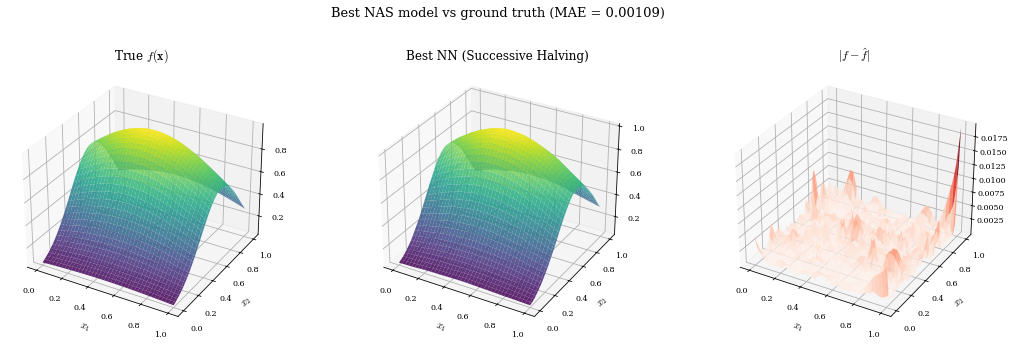

In [10]:
# ----------------------------------------------------------------
# Figure 2: best-model surface (saved as nas_best_surface.{pdf,png})
# ----------------------------------------------------------------
# We retrain the best config (across both searches) for a generous epoch
# budget so the surface plot reflects the architecture, not the search
# transient.

best_overall = min([best_random, best_sha], key=lambda r: r["val_loss"])
best_method  = "Random Search" if best_overall is best_random else "Successive Halving"
print(f"Best overall method : {best_method}")
print(f"Best config         : {best_overall['config']}")
print(f"  val_loss = {best_overall['val_loss']:.3e}, MAE = {best_overall['mae']:.5f}")

# Re-fit the winner with a longer budget for a clean surface
final_rec, final_model = build_and_train(
    best_overall["config"], epochs=300,
    X_tr=X_train, y_tr=y_train,
    X_val=X_test, y_val=y_test,
    patience=30,
)
print(f"Re-fit MAE = {final_rec['mae']:.5f} after {final_rec['epochs']} epochs")

# Build evaluation grid
grid_n = 80
t_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(t_grid, t_grid)
X_grid = np.column_stack([X1.ravel(), X2.ravel()]).astype(np.float32)

Z_true = genz_gaussian(X_grid, c_param, w_param).reshape(grid_n, grid_n)
Z_pred = final_model.predict(X_grid, verbose=0).reshape(grid_n, grid_n)
Z_err  = np.abs(Z_true - Z_pred)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6),
                         subplot_kw={"projection": "3d"})

axes[0].plot_surface(X1, X2, Z_true, cmap="viridis", alpha=0.85,
                     edgecolor="none", rcount=60, ccount=60)
axes[0].set_title(r"True $f(\mathbf{x})$", fontsize=12)

axes[1].plot_surface(X1, X2, Z_pred, cmap="viridis", alpha=0.85,
                     edgecolor="none", rcount=60, ccount=60)
axes[1].set_title(f"Best NN ({best_method})", fontsize=12)

axes[2].plot_surface(X1, X2, Z_err, cmap="Reds", alpha=0.85,
                     edgecolor="none", rcount=60, ccount=60)
axes[2].set_title(r"$|f - \hat f|$", fontsize=12)

for ax in axes:
    ax.set_xlabel(r"$x_1$", fontsize=10)
    ax.set_ylabel(r"$x_2$", fontsize=10)
    ax.tick_params(labelsize=8)

fig.suptitle(f"Best NAS model vs ground truth (MAE = {Z_err.mean():.5f})",
             fontsize=13, y=1.02)
fig.tight_layout()

surf_pdf = "../figures/nas_best_surface.pdf"
surf_png = "../figures/nas_best_surface.png"
plt.savefig(surf_pdf, bbox_inches="tight")
plt.savefig(surf_png, dpi=180, bbox_inches="tight")
plt.show()


---
## 7. Discussion

### Key observations

1. **Both automated methods beat the fixed baseline.** Even with only 30
   trials, Random Search finds an architecture better than our intuition-driven
   $3 \times 64$ ReLU choice (Bergstra & Bengio, 2012).

2. **Random Search is a surprisingly strong baseline.** Sampling
   independently across all hyperparameters covers the important dimensions
   well, especially when only a few axes matter (here, learning rate and
   width).

3. **Successive Halving spends compute where it pays off.** By killing
   poorly-initialized configs after $r_0 = 8$ epochs, SHA reallocates the
   budget to the long tail of survivors. Hyperband (Li et al., 2018) wraps SHA
   in an outer loop over different initial $(n_0, r_0)$ pairs to hedge against
   the early-stopping bias.

4. **Bayesian Optimisation** (not implemented here) typically matches or
   slightly beats Random Search on smooth, low-dimensional response surfaces,
   at the cost of a sequential bottleneck. We cover the GP + Expected
   Improvement machinery in **Day 7** (Surrogates, GPs, and Bayesian
   Estimation).

### When does NAS matter in economics?

- **Surrogate models.** When replacing expensive simulations (climate
  models, agent-based models) with neural networks, architecture choice
  directly determines approximation quality.

- **Policy function approximation.** In deep equilibrium nets (Session 1),
  the NN approximates policy/value functions. NAS can automate the
  architecture selection that is usually done by hand.

- **Diminishing returns.** For simple functions ($d \leq 5$), 30 random
  trials is usually enough. For high-dimensional problems, the budget should
  scale with input dimension, and SHA / Hyperband become essential to keep
  wall-clock time tractable.

### Production tooling (footnote)

The from-scratch loops above are pedagogical. In practice you would reach for:

- **KerasTuner** -- the most natural fit for TF/Keras workflows
- **Optuna** -- framework-agnostic, define-by-run search spaces
- **Ray Tune** -- distributed trials, integrates with PBT and HEBO
- **Hyperopt** -- TPE algorithm out of the box
- **Ax / BoTorch** -- modern Bayesian optimization on PyTorch
- **NNI**, **AutoKeras** -- broader AutoML pipelines

Every one of these libraries implements the algorithms above (and a few more)
under the hood. Knowing the algorithm makes it easier to read their docs and
to debug when a search underperforms.

### References

- Bergstra, J., & Bengio, Y. (2012). *Random search for hyper-parameter
  optimization.* JMLR 13, 281-305.
- Li, L., Jamieson, K., DeSalvo, G., Rostamizadeh, A., & Talwalkar, A. (2018).
  *Hyperband: A novel bandit-based approach to hyperparameter optimization.*
  JMLR 18(185), 1-52.
- Garnett, R. (2023). *Bayesian optimization.* Cambridge University Press.
- Snoek, J., Larochelle, H., & Adams, R. P. (2012). *Practical Bayesian
  optimization of machine learning algorithms.* NeurIPS.